In [1]:
import mdtraj as md
import numpy as np
import scipy
from scipy.stats import linregress
import matplotlib.pyplot as plt
from itertools import combinations
import sys, os, re
from msmbuilder.decomposition import tICA as msm_tICA
from msmbuilder.featurizer import AtomPairsFeaturizer

sys.path.append(os.path.dirname(os.getcwd())) 
import amuset_tica

In [2]:
tics_of_trajs = np.load("9d9f_inv_2tics.npy")
print(tics_of_trajs.shape)
# 40 trajs for 4 us, 50,000 frames, 2 tics
# memory kernel decay in approx 25 frames (1 frame = 2 ps)

(40, 50001, 2)


## tICA

In [3]:
def calc_Koopman_op (tics_of_trajs, traj_n, traj_len, tICA_lag):
    x_of_input, y_of_input = [], []
    for i in range(traj_n):
        if i == 0:
            x_of_input = tics_of_trajs[i, :-tICA_lag, :]
            y_of_input = tics_of_trajs[i, tICA_lag:, :]
        else:
            x_of_input = np.concatenate((x_of_input, tics_of_trajs[i, :-tICA_lag, :]))
            y_of_input = np.concatenate((y_of_input, tics_of_trajs[i, tICA_lag:, :]))

    x_of_input = x_of_input.T
    y_of_input = y_of_input.T
    mu = x_of_input.mean(axis=1, keepdims=True)
    x_of_input = x_of_input - mu
    y_of_input = y_of_input - mu
    C00 = np.matmul(x_of_input, x_of_input.T)
    C11 = np.matmul(y_of_input, y_of_input.T)
    C01 = np.matmul(x_of_input, y_of_input.T)

    #return np.linalg.solve(C00, C01)
    return np.linalg.solve(C00+C11, C01+C01.T)


10 [136.98444063140553, 14.896829188610862]
20 [197.11899305064128, 21.095569189623316]
30 [236.83989863544883, 25.45673359056563]
40 [265.43015528895694, 28.69920055356582]
50 [287.30352332297053, 31.36433557873811]
60 [304.7721100822873, 33.60873465403756]
70 [318.8002329571335, 35.2693171663172]
80 [330.3899920957232, 36.813756304897424]
90 [340.2766443041737, 37.99820736332995]
100 [347.833129475776, 39.003715102019164]
110 [354.94636698782784, 40.0033225095837]
120 [360.93637073486263, 41.277655208386555]
130 [366.15479254219525, 42.45607178542845]
140 [370.84212487710573, 43.30230351597291]
150 [375.283518789584, 44.609331896326154]
160 [379.42770314933756, 45.974838226021745]
170 [383.09475224140283, 46.55872847002888]
180 [386.65154855088235, 46.833642375620784]
190 [389.3763517639457, 47.56827926465992]
200 [392.3699842076839, 48.80708950333197]


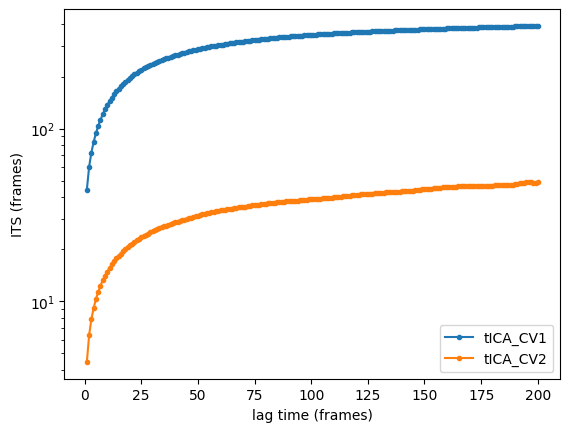

In [5]:
ITS_tICA = []
for lag in range(1, 201):
    K_tICA = calc_Koopman_op(tics_of_trajs, 40, 50001, tICA_lag=lag)
    EigK = np.linalg.eig(K_tICA)[0]
    ITS_tICA.append([-lag/np.log(EigK[0]), -lag/np.log(EigK[1])])
    if lag % 10 == 0:
        print(lag, ITS_tICA[-1])
ITS_tICA = np.array(ITS_tICA).T

fig1, ax1 = plt.subplots()
ax1.set_yscale('log')
plt.xlabel("lag time (frames)")
plt.ylabel("ITS (frames)")
ax1.plot(range(1, 201), ITS_tICA[0], '.-', label='tICA_CV1') 
ax1.plot(range(1, 201), ITS_tICA[1], '.-', label='tICA_CV2')
plt.legend()
plt.show()

## AMUSET-TICA

In [4]:
basis_list = amuset_tica.Basis.find(tics_of_trajs, [2,2], sigma=2, mix=True)
print(basis_list)

ttica = amuset_tica.AmusetTICA()
svd_v, traj_lens = ttica.build(basis_list, tics_of_trajs)

[[[-1.0939795878279368, 2], [0.6151525780598074, 2], [0.6025909988440169, 2], [-0.9219408339178378, 2]], [[-1.0939795878279368, 2], [0.6151525780598074, 2], [0.6025909988440169, 2], [-0.9219408339178378, 2]]]


Time = 1 frames
[129.58887189  12.06051611   5.13217502   3.1881491    2.61739813
   2.15899844]
Time = 2 frames
[171.54323037  16.1761547    6.82288475   4.35012552   3.58880428
   2.98997918]
Time = 3 frames
[200.12163699  18.98586236   8.04715947   5.15987274   4.31146401
   3.59987362]
Time = 4 frames
[221.78680845  21.11672625   9.02032293   5.79551858   4.91834685
   4.08902551]
Time = 5 frames
[238.91215446  22.82879804   9.84830873   6.3424382    5.4655156
   4.52311059]
Time = 6 frames
[253.10064744  24.25791021  10.57900136   6.81330052   5.95198439
   4.91769537]
Time = 7 frames
[265.02187886  25.45344     11.22517745   7.23417413   6.40020589
   5.27990767]
Time = 8 frames
[275.43897928  26.50979679  11.83308653   7.61238295   6.83312655
   5.6500828 ]
Time = 9 frames
[284.65217448  27.45974524  12.38449574   7.99107955   7.24883563
   6.0055761 ]
Time = 10 frames
[292.63652887  28.26857273  12.89952388   8.34873031   7.60191126
   6.32976992]
Time = 11 frames
[299.83627227

Time = 85 frames
[412.36278711  44.49122578  29.7497755   22.72866641  18.46391803
  17.735685  ]
Time = 86 frames
[412.7364378   44.58717445  29.83761506  22.72299916  18.51935639
  17.84051203]
Time = 87 frames
[413.08926941  44.69147724  29.91876632  22.89726222  18.62453412
  18.27925004]
Time = 88 frames
[413.40360148  44.76951951  30.13040986  23.15461763  18.98389801
  18.29955224]
Time = 89 frames
[413.70331234  44.8606873   30.2792297   23.25669975  19.00867133
  18.18114495]
Time = 90 frames
[413.9863106   44.88748535  30.2613561   23.26695015  18.99058098
  18.49569742]
Time = 91 frames
[414.30541977  44.91882583  30.14934787  23.42665118  19.38887594
  18.65008052]
Time = 92 frames
[414.59351983  44.98322632  30.13762792  23.55813222  19.45490471
  18.59572414]
Time = 93 frames
[414.89362783  45.06813267  30.34365998  23.70243082  19.84592097
  18.54575511]
Time = 94 frames
[415.21215879  45.12348375  30.35087729  23.85332658  20.0881688
  18.95537761]
Time = 95 frames
[415

Time = 168 frames
[428.96240689  52.40521626  37.68362198  33.78202845  33.55318577
  31.45802859]
Time = 169 frames
[429.09648122  52.4671853   37.72246566  33.9653815   32.871317
  31.19903598]
Time = 170 frames
[429.25467488  52.56718498  37.59607018  33.87096323  32.63627656
  32.01953975]
Time = 171 frames
[429.42745098  52.65940705  37.76080647  33.72024473  33.10438853
  32.04733507]
Time = 172 frames
[429.56554026  52.81562779  38.02238311  33.33695445  32.878929
  32.16182016]
Time = 173 frames
[429.71364992  52.89462776  38.28719888  34.14823714  33.2724956
  32.05844538]
Time = 174 frames
[429.8750672   53.03765493  38.5415799   34.36271265  33.97573053
  33.57425174]
Time = 175 frames
[430.01914287  53.04291677  38.40951442  34.70666488  33.66535523
  33.03002132]
Time = 176 frames
[430.19273327  53.11475037  38.439512    34.64858762  33.40888776
  32.75969704]
Time = 177 frames
[430.3644146   53.20272575  39.07514527  35.49730449  34.52074573
  34.31826912]
Time = 178 fram

Time = 251 frames
[438.52214158  59.71679845  50.94740256  46.61980197  46.17307927
  45.17300058]
Time = 252 frames
[438.61792282  59.93296547  47.44875822  45.43978542  44.79082811
  44.20824635]
Time = 253 frames
[438.69366722  60.15651938  48.34645024  46.67997869  44.73308399
  43.4865313 ]
Time = 254 frames
[438.79802451  60.61356362  48.62580629  47.09303429  45.9194869
  44.25241487]
Time = 255 frames
[438.88858165  60.80845195  47.97048015  45.56874072  45.38715994
  43.98330622]
Time = 256 frames
[438.96295269  60.80992969  49.24643792  46.78449638  46.42399333
  44.2093107 ]
Time = 257 frames
[439.04350666  60.88437442  48.56002855  47.095023    45.12827659
  44.39879005]
Time = 258 frames
[439.1233892   60.90270236  49.27833173  47.51421117  46.72863762
  45.18448833]
Time = 259 frames
[439.18853917  60.85095173  49.32340282  46.60312724  46.28034009
  45.57307854]
Time = 260 frames
[439.24930067  61.02067642  51.4913928   47.27859743  46.53085968
  44.29696094]
Time = 261 

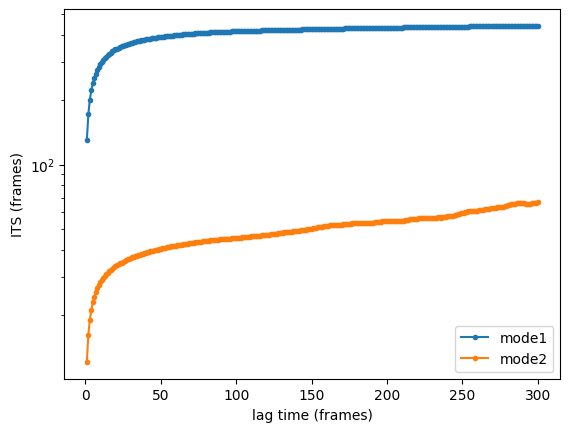

Current date and time: 2026-03-16 11:26:44.049490


In [5]:
ITSs = []
lag_times = list(range(1, 301))
Ks, Es, Vs = [], [], []

for i in lag_times:
    ttica.covariance(svd_v, traj_lens, lag_time=i)
    Ks.append(ttica._K)
    evK, vrK = np.linalg.eig(ttica._K)
    idx = np.argsort(evK)[::-1]
    evK = evK[idx]
    vrK = vrK[:,idx]
    
    Es.append(evK)
    Vs.append(vrK)
    print("Time =", i, 'frames')
    ITSs.append(ttica.timescales_[:6])
    print(ITSs[-1])

fig1, ax1 = plt.subplots()
ax1.set_yscale('log')
plt.xlabel("lag time (frames)")
plt.ylabel("ITS (frames)")

ITS = np.array(ITSs).T
print("ITS.shape =", ITS.shape)
for i in range(2):#(ITS.shape[0]):
    ax1.plot(lag_times, ITS[i], '.-', label='mode'+str(i+1)) 

plt.legend()
plt.show()

from datetime import datetime
print(f"Current date and time: {datetime.now()}")

In [6]:
Ks = np.asarray(Ks)
print(Ks.shape)
np.save('9d9f_Ks.npy', Ks)

(300, 25, 25)


Time = 1 frames
[129.58887188604098, 12.060516105962474, 5.1321750202900205, 3.188149100422746, 2.6173981305822247]
Time = 11 frames
[299.8362722741729, 29.00806046894122, 13.380841973462962, 8.691319017893125, 7.9325105620330625]
Time = 21 frames
[346.4506726845603, 33.96898311528695, 17.299723761597555, 11.622606294764605, 10.456630957229908]
Time = 31 frames
[369.1068833017759, 36.98467528304016, 20.273948733888705, 13.66849322046339, 12.656995245425827]
Time = 41 frames
[383.14237236002515, 39.04530150365755, 22.847991058932536, 15.266155858303495, 14.598561311698035]
Time = 51 frames
[392.90136831660277, 40.664134813517464, 24.923853478913017, 16.719176588156245, 16.4745355400208]
Time = 61 frames
[400.6450421886354, 42.10387765874852, 26.627644634002216, 18.18274128409274, 17.39874017634789]
Time = 71 frames
[406.4241955551415, 43.20960415781666, 27.89464784905572, 19.99045211938814, 18.18004617188386]
Time = 81 frames
[410.7657978016695, 44.13993490276023, 29.313649791555196, 21

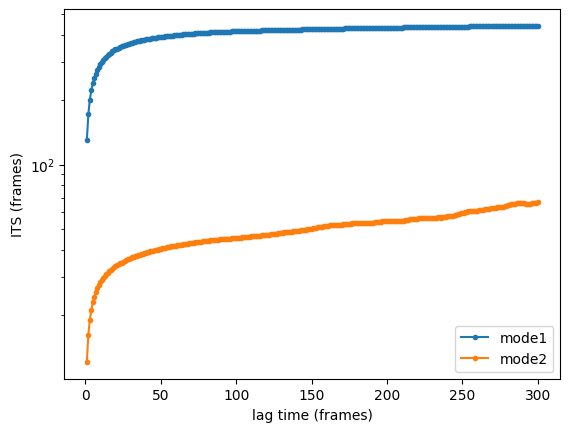

Current date and time: 2026-03-21 20:56:41.208136


In [11]:
Ks = np.load("9d9f_Ks.npy")
ITSs = []
lag_times = list(range(1, 301))
Es, Vs = [], []

for i in range(len(lag_times)):
    evK, vrK = np.linalg.eig(Ks[i])
    idx = np.argsort(evK)[::-1]
    evK = evK[idx]
    vrK = vrK[:,idx]
    
    Es.append(evK)
    Vs.append(vrK)
    ITSs.append([-lag_times[i]/np.log(Es[-1][j]) for j in range(1,6)])
    if i % 10 == 0:
        print("Time =", lag_times[i], 'frames')
        print(ITSs[-1])

fig1, ax1 = plt.subplots()
ax1.set_yscale('log')
plt.xlabel("lag time (frames)")
plt.ylabel("ITS (frames)")

ITS = np.array(ITSs).T
print("ITS.shape =", ITS.shape)
for i in range(2):#(ITS.shape[0]):
    ax1.plot(lag_times, ITS[i], '.-', label='mode'+str(i+1)) 

plt.legend()
plt.show()

from datetime import datetime
print(f"Current date and time: {datetime.now()}")

## A.T.-IGME and comparison

In [17]:
ITS_Mhat = []
for i in range(10, 200):
    st = i-20 if i>=40 else i//2
    M_hat, _ = fit_M_from_K_sequence(Ks[:i+1], st, 1, enforce_hermitian_M=False)
    evK, vrK = np.linalg.eig(M_hat)
    evK = np.abs(evK)
    evK = evK[np.argsort(evK)[::-1]]
    idx = 0
    while evK[idx] - 1 > 1e-5:
        idx += 1
    cur_ITS = [-1/np.log(evK[idx+_]) for _ in range(1,6)]
    ITS_Mhat.append(cur_ITS)
    print(i, cur_ITS)
ITS_IGME = np.array(ITS_Mhat).T
print(ITS_IGME.shape)

10 [397.69801940218025, 39.14840750313538, 22.25055541983807, 16.0969766878741, 13.99946392478005]
11 [399.9405011368994, 39.39173495450878, 22.73858350301752, 16.326742319749393, 14.50134898209638]
12 [407.74591456982347, 40.92793279829688, 25.371043254671303, 16.927184950001767, 16.00252913692655]
13 [410.5017831866199, 41.265317964718754, 25.708214243105065, 17.243086481243786, 16.350199616516466]
14 [416.334776613443, 42.5307757479009, 27.7029687908143, 18.306617082405655, 17.13087017279775]
15 [418.4119760757278, 42.88198411037503, 28.083190427029713, 17.981330174693383, 17.101126590003293]
16 [422.72074244724314, 44.0280461476149, 29.177856433580637, 21.036048719173856, 17.876971582584492]
17 [424.12542503829735, 44.28978928440047, 29.296516672323207, 20.063260248047126, 17.878682731303023]
18 [428.1681236271437, 45.06372884319382, 30.107088326861376, 20.078118308406058, 18.157584573791848]
19 [429.82480180614095, 45.67776440807804, 30.804584976932077, 20.969370211351674, 18.3702

108 [444.2816986098221, 53.444803035615195, 37.91885432094889, 32.47396443742299, 22.261634409218956]
109 [445.054355881218, 53.23277487948502, 37.22843367047902, 29.740029392202974, 20.27374890004444]
110 [444.9239351190991, 53.62672703517349, 40.73099495448218, 32.21507664355006, 19.38057383351615]
111 [445.1336511661714, 54.14891135859313, 40.86924875088885, 30.55727883504918, 24.339043976440763]
112 [445.2442625792833, 52.479049886606454, 39.69393815192566, 29.499374822254637, 26.798419822001556]
113 [445.4089378621612, 54.58357688043639, 41.09526045505654, 32.66501808858307, 23.805610293100067]
114 [446.2377640729171, 54.637546423946134, 40.755585320196666, 35.388365210528676, 22.129121692172955]
115 [447.1464541438203, 55.203539223903334, 43.282291690410496, 38.60893450825031, 22.853497146105568]
116 [447.62337615839334, 57.03212793767355, 44.36982283427576, 35.587014469460016, 18.67340747720708]
117 [447.8056486991793, 56.450060372745014, 45.618990970071415, 37.42475000324295, 1

In [18]:
ITS_tICA.shape, ITS.shape, ITS_IGME.shape

((2, 200), (5, 300), (5, 190))

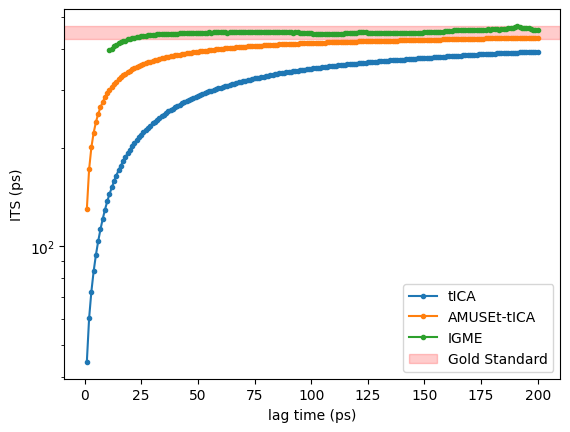

Current date and time: 2026-03-21 21:00:59.082540


In [19]:
ITS_AT = ITS

fig, ax = plt.subplots()
ax.set_yscale('log')
plt.xlabel("lag time (ps)")
plt.ylabel("ITS (ps)")

time_len = 200
ax.plot(range(1,time_len+1), ITS_tICA[0][:time_len], '.-', label='tICA')
ax.plot(range(1,time_len+1), ITS_AT[0][:time_len], '.-', label='AMUSEt-tICA')
ax.plot(range(11,time_len+1), ITS_IGME[0][:time_len-10], '.-', label='IGME') 
y_max, y_min = 430, 470
plt.axhspan(y_min, y_max, color='red', alpha=0.2, label='Gold Standard')

plt.legend()
plt.show()

from datetime import datetime
print(f"Current date and time: {datetime.now()}")

In [20]:
usage_ITS='''
fig, ax = plt.subplots()
ax.set_yscale('log')
plt.xlabel("lag time (ps)")
plt.ylabel("ITS (ps)")

time_len = 200
ax.plot(range(1,time_len+1), ITS_tICA[0][:time_len], '.-', label='tICA')
ax.plot(range(1,time_len+1), ITS_AT[0][:time_len], '.-', label='AMUSEt-tICA')
ax.plot(range(11,time_len+1), ITS_IGME[0][:time_len-10], '.-', label='IGME') 
y_max, y_min = 430, 470
plt.axhspan(y_min, y_max, color='red', alpha=0.2, label='Gold Standard')

plt.legend()
plt.show()
'''
np.savez('Panel_1d_ITS.npz', ITS_tICA=ITS_tICA, ITS_AT=ITS_AT, ITS_IGME=ITS_IGME, usage=usage_ITS)

In [21]:
np.load('Panel_1d_ITS.npz')

NpzFile 'Panel_1d_ITS.npz' with keys: ITS_tICA, ITS_AT, ITS_IGME, usage